# Large Geolocalised European Grid Simulation with Pandapower
### Course: ELEC0447 - Analysis of Electric Power and Energy Systems
**Instructors**: Bertrand Cornélusse, Francesco Moglia (University of Liège)

---

## 1. Context & Objectives
In modern power systems, the transition towards decarbonized energy requires integrating massive volumes of distributed renewable energy sources (RES)—predominantly solar photovoltaics (PV) and wind—into distribution and sub-transmission networks.

This notebook demonstrates a complete, industrial-grade simulation workflow using **pandapower** on a large, realistic European benchmark network:
- **Network**: **Oberrhein 20 kV Medium Voltage (MV) Grid** (`mv_oberrhein`)
- **Scale**: **179 buses**, **181 lines**, **147 consumer loads**, **153 distributed solar PV plants**, and **2 primary HV/MV substations** (110 kV / 20 kV).
- **Geolocalisation**: Real GPS coordinates in the Upper Rhine (Oberrhein) valley, Germany.

### Notebook Contents:
1. **Network Loading & GIS Inspection**: Inspecting topology, substations, and geographic layout.
2. **Baseline AC Power Flow Analysis**: Solving Newton-Raphson power flow, assessing bus voltage profiles and line thermal loadings.
3. **Interactive OpenStreetMap Visualization**: Displaying the grid geospatially with voltage and loading color scales.
4. **Contingency Analysis ($N-1$ & Generator Tripping)**:
   - Systematically screening $N-1$ line outages to identify critical bottleneck corridors.
   - Tripping renewable generation clusters to observe local voltage collapse and slack redispatch.
5. **Multi-Period Time-Series Simulation (24-Hour Profile)**:
   - Simulating realistic diurnal demand evolution and solar irradiance variation.
   - Observing the **Reverse Power Flow** phenomenon (feed-in export back to the transmission grid).
   - Analyzing time-dependent bus voltage envelopes $[V_{\min}(t), V_{\max}(t)]$ and dynamic feeder congestion.

In [1]:
%matplotlib inline
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

# Silence pandapower internal numba logs
import logging
logging.getLogger("pandapower").setLevel(logging.ERROR)
import pandapower as pp
import pandapower.networks as pn

# Import our modular analysis library
from large_network_analysis import (
    get_european_network,
    run_baseline_power_flow,
    simulate_line_tripping,
    simulate_gen_tripping,
    run_n1_contingency_screening,
    generate_diurnal_profiles,
    run_timeseries_powerflow,
    plot_voltage_and_loading_profiles,
    plot_contingency_comparison,
    plot_timeseries_dashboard,
    create_interactive_map,
    extract_geodata_tables
)

print(f"pandapower version: {pp.__version__}")
print("Simulation environment successfully initialized.")

pandapower version: 3.1.2
Simulation environment successfully initialized.


---
## 2. Network Topology & Geographic Exploration
We load the **Oberrhein 20 kV** benchmark network. We configure it in **meshed operation** (closing the normally-open tie switches) to model closed loops that allow parallel power flow rerouting and realistic $N-1$ contingency behavior.

In [2]:
net = get_european_network(network_name="mv_oberrhein", scenario="generation", meshed=True)

print("--- Oberrhein Network Characteristics ---")
print(f"Number of buses:              {len(net.bus)}")
print(f"Number of lines:              {len(net.line)}")
print(f"Number of transformers:       {len(net.trafo)}")
print(f"Number of consumer loads:     {len(net.load)}")
print(f"Number of static generators:  {len(net.sgen)} (Solar PV)")
print(f"Number of external grids:     {len(net.ext_grid)} (110 kV primary substations)")

# Extract and inspect GIS coordinates
bus_coords_df, line_coords_dict = extract_geodata_tables(net)
print(f"\nGeolocated buses: {len(bus_coords_df)} / {len(net.bus)}")
print(f"Geolocated lines: {len(line_coords_dict)} / {len(net.line)}")
print(f"Geographic Bounding Box: Lon [{bus_coords_df['lon'].min():.3f}, {bus_coords_df['lon'].max():.3f}], Lat [{bus_coords_df['lat'].min():.3f}, {bus_coords_df['lat'].max():.3f}]")

bus_coords_df.head()

--- Oberrhein Network Characteristics ---
Number of buses:              179
Number of lines:              181
Number of transformers:       2
Number of consumer loads:     147
Number of static generators:  153 (Solar PV)
Number of external grids:     2 (110 kV primary substations)

Geolocated buses: 179 / 179
Geolocated lines: 181 / 181
Geographic Bounding Box: Lon [7.744, 7.938], Lat [48.328, 48.475]


,lon,lat
0,7.765226,48.410916
1,7.778810,48.409871
2,7.779196,48.412038
3,7.775205,48.406103
4,7.766065,48.412424


---
## 3. Baseline AC Power Flow Simulation (Newton-Raphson)
We now execute the full non-linear AC power flow equations:
$$\begin{aligned}
P_i &= V_i \sum_{k=1}^N V_k \left( G_{ik} \cos(\theta_i - \theta_k) + B_{ik} \sin(\theta_i - \theta_k) \right) \\
Q_i &= V_i \sum_{k=1}^N V_k \left( G_{ik} \sin(\theta_i - \theta_k) - B_{ik} \cos(\theta_i - \theta_k) \right)
\end{aligned}$$
using the Newton-Raphson algorithm (`pp.runpp`).

In [3]:
base_res = run_baseline_power_flow(net)

summary_table = pd.DataFrame([
    {"Metric": "Power Flow Status", "Value": "Converged" if base_res["converged"] else "Diverged"},
    {"Metric": "Total Connected Load (MW)", "Value": f"{base_res['p_load_mw']:.2f}"},
    {"Metric": "Total Connected Load (MVAr)", "Value": f"{base_res['q_load_mvar']:.2f}"},
    {"Metric": "Total Solar Generation (MW)", "Value": f"{base_res['p_sgen_mw']:.2f}"},
    {"Metric": "Substation Power Exchange (MW)", "Value": f"{base_res['p_ext_grid_mw']:.2f} (Export to HV)"},
    {"Metric": "Total Network Losses (MW)", "Value": f"{base_res['p_loss_mw']:.3f}"},
    {"Metric": "Minimum Bus Voltage", "Value": f"{base_res['v_min']:.4f} p.u. (Bus {base_res['v_min_bus']})"},
    {"Metric": "Maximum Bus Voltage", "Value": f"{base_res['v_max']:.4f} p.u. (Bus {base_res['v_max_bus']})"},
    {"Metric": "Average Bus Voltage", "Value": f"{base_res['v_mean']:.4f} p.u."},
    {"Metric": "Maximum Line Loading", "Value": f"{base_res['max_loading_percent']:.2f}% (Line {base_res['max_loading_line']})"},
    {"Metric": "Average Line Loading", "Value": f"{base_res['mean_loading_percent']:.2f}%"},
    {"Metric": "Voltage Limit Violations (<0.95 or >1.05 pu)", "Value": f"{len(base_res['under_voltage_buses']) + len(base_res['over_voltage_buses'])}"}
])

summary_table

,Metric,Value
0,Power Flow Status,Converged
1,Total Connected Load (MW),6.19
2,Total Connected Load (MVAr),1.26
3,Total Solar Generation (MW),17.66
4,Substation Power Exchange (MW),-11.34 (Export to HV)
5,Total Network Losses (MW),0.130
6,Minimum Bus Voltage,1.0000 p.u. (Bus 58)
7,Maximum Bus Voltage,1.0148 p.u. (Bus 159)
8,Average Bus Voltage,1.0122 p.u.
9,Maximum Line Loading,22.47% (Line 161)


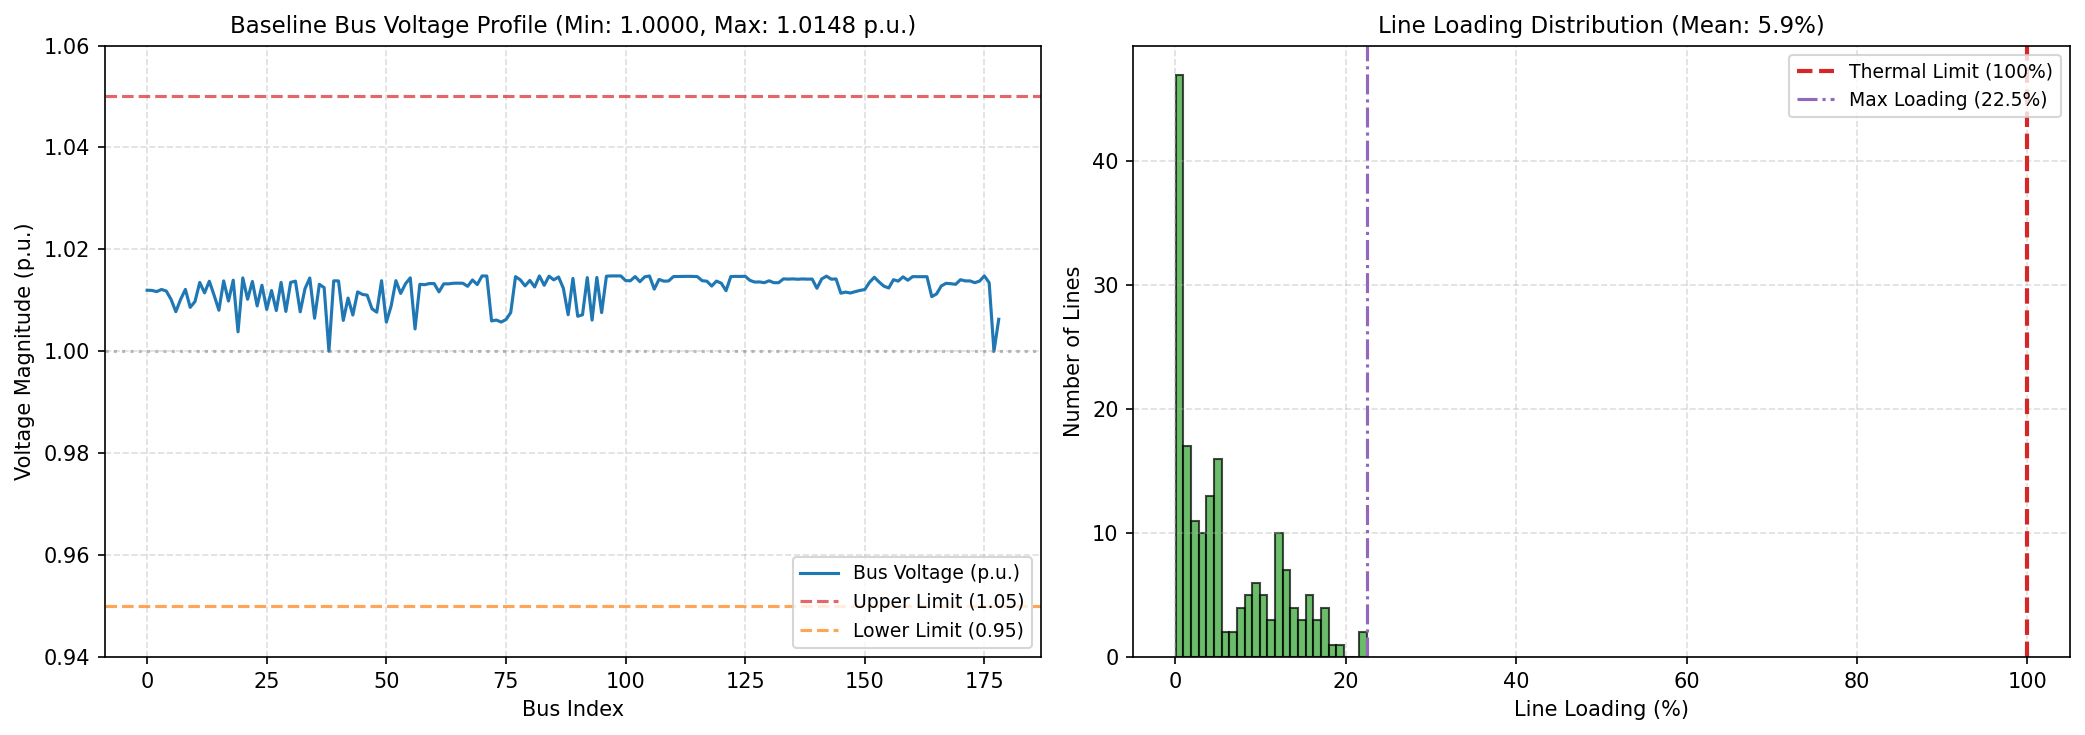

In [4]:
fig_base = plot_voltage_and_loading_profiles(net, base_res)
plt.show()

---
## 4. Interactive Geolocalised Map (OpenStreetMap)
Below is an interactive GIS visualization rendered with Plotly MapLibre and OpenStreetMap:
- **Lines** are colored by loading: green ($<40\%$), orange ($40-70\%$), red ($70-100\%$).
- **Buses** are color-coded by voltage magnitude (p.u.).
- **Substations** are highlighted as purple squares.
- Hover over any line or bus to inspect real-time electrical quantities ($P, Q, I, V$).

In [5]:
fig_map = create_interactive_map(net)
fig_map.show()

---
## 5. Contingency Analysis: Line ($N-1$) and Generator Trippings

### 5.1 Automated $N-1$ Line Screening
In power system security analysis, the $N-1$ criterion requires that any single element outage must not cause cascading line thermal overloads or voltage collapses.

We systematically trip candidate lines in the network and evaluate:
1. Post-contingency maximum line loading.
2. The maximum surge in loading on parallel corridors (rerouting effect).
3. The number of resulting thermal overloads ($>100\%$ rating).

In [6]:
n1_results = run_n1_contingency_screening(net, top_candidates=8)
n1_results

,tripped_line,base_loading_%,post_max_loading_%,most_loaded_line,n_overloaded,overloaded_lines,max_loading_increase_%,most_impacted_line,post_v_min_pu,max_voltage_drop_pu
0,161,22.472404,33.099430,179,0,[],19.983933,189,1.0,-0.004928
1,183,22.446396,33.080585,179,0,[],19.964761,189,1.0,-0.005414
2,54,19.001593,28.411463,161,0,[],13.997016,24,1.0,-0.006489
3,36,18.511166,28.270829,161,0,[],13.642276,24,1.0,-0.006935
5,37,17.752659,28.022434,161,0,[],13.069259,24,1.0,-0.006999
7,151,17.273945,27.873303,161,0,[],12.713189,24,1.0,-0.007238
4,27,17.764560,27.226628,161,0,[],11.205913,24,1.0,-0.007220
6,181,17.520890,27.207611,59,0,[],12.818443,188,1.0,-0.004337


### 5.2 Critical Line Outage & Renewable Generator Tripping
We now simulate:
1. **Line Outage**: Tripping the most critical line identified by the $N-1$ screening.
2. **Generator Tripping**: Sudden tripping of a cluster of the 5 largest solar PV plants ($2.91$ MW). We observe the resulting local voltage drops and the shift in power import through the primary HV/MV substations.

--- Impact of Tripping Line 161 ---
Post-contingency max line loading: 33.10% (Line 179)
Loading increase on adjacent corridor: +19.98% (Line 189)

--- Impact of Tripping 2.91 MW PV Cluster ---
Substation import shifted by: +2.30 MW (HV grid compensates for lost generation)
Max voltage drop: -0.0021 p.u. at Bus 33


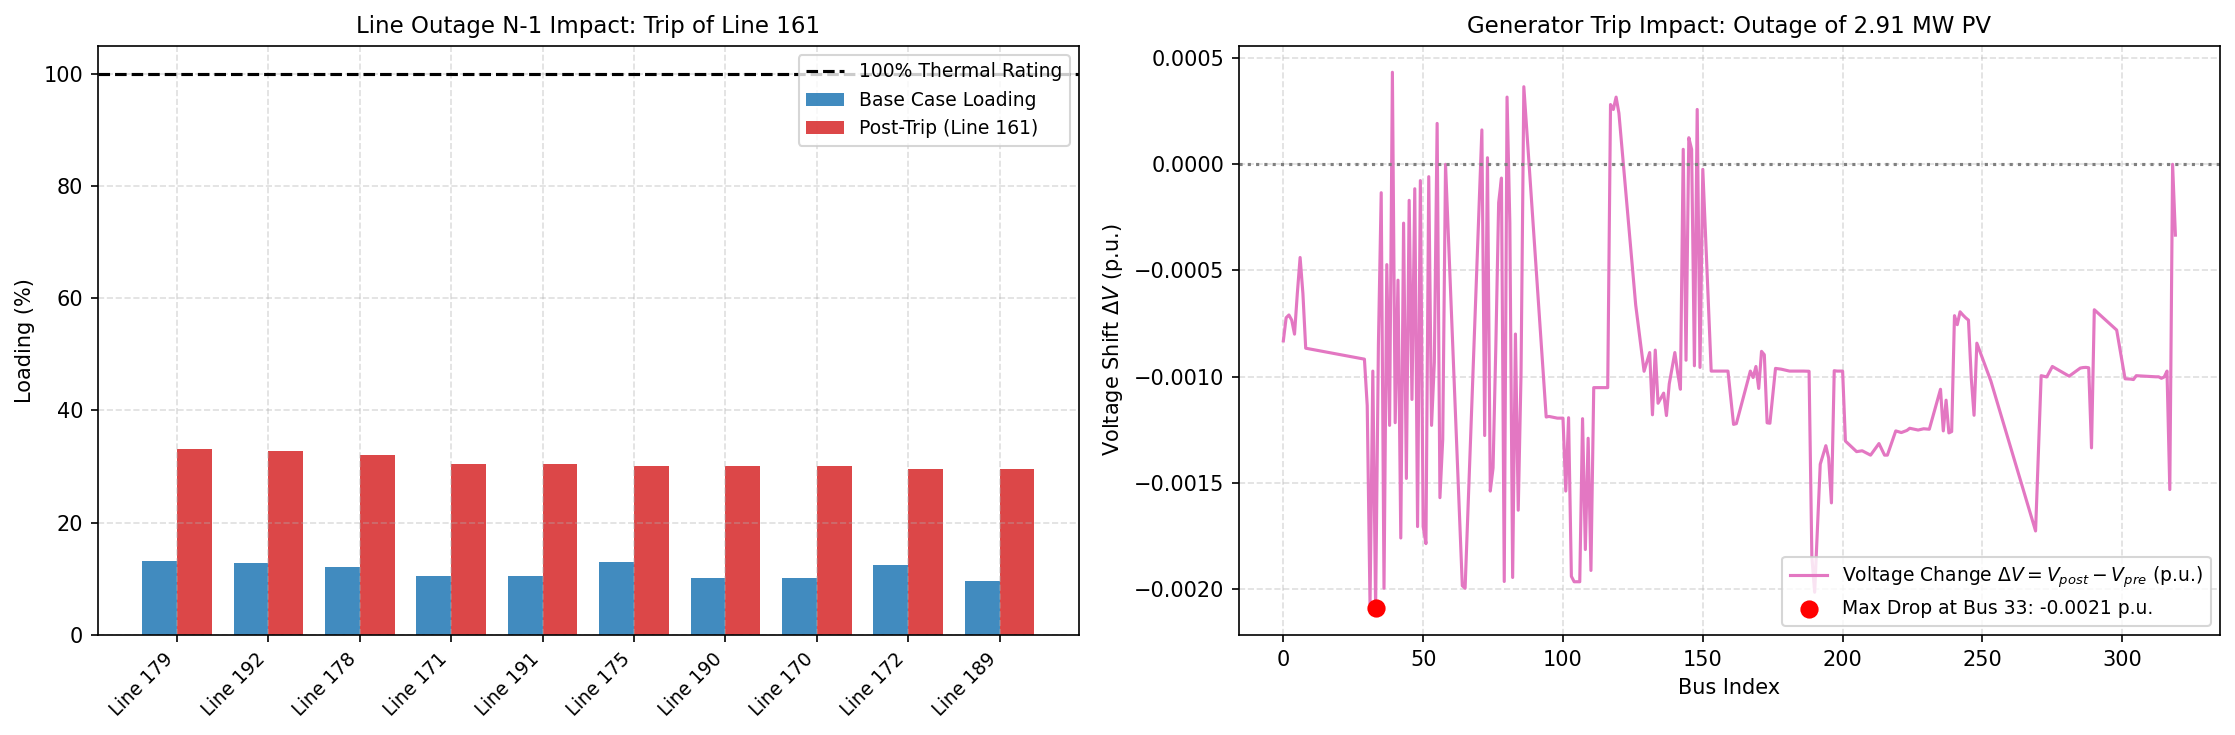

In [7]:
critical_line = int(n1_results.iloc[0]["tripped_line"])
line_cont_res = simulate_line_tripping(net, critical_line)

top_pv = net.sgen.sort_values(by="p_mw", ascending=False).head(5)
gen_trip_ids = top_pv.index.tolist()
gen_cont_res = simulate_gen_tripping(net, gen_trip_ids)

print(f"--- Impact of Tripping Line {critical_line} ---")
print(f"Post-contingency max line loading: {line_cont_res['max_loading_percent']:.2f}% (Line {line_cont_res['max_loading_line']})")
print(f"Loading increase on adjacent corridor: +{line_cont_res['max_loading_increase']:.2f}% (Line {line_cont_res['max_loading_increase_line']})")

print(f"\n--- Impact of Tripping {gen_cont_res['tripped_p_mw']:.2f} MW PV Cluster ---")
print(f"Substation import shifted by: {gen_cont_res['delta_ext_grid_p_mw']:+.2f} MW (HV grid compensates for lost generation)")
print(f"Max voltage drop: {gen_cont_res['max_voltage_drop']:.4f} p.u. at Bus {gen_cont_res['max_voltage_drop_bus']}")

fig_cont = plot_contingency_comparison(net, line_cont_res, gen_cont_res)
plt.show()

---
## 6. Multi-Period Time-Series Simulation (24-Hour Profile)
Power flows are inherently non-stationary. Here we simulate a full 24-hour cycle combining:
1. **Diurnal Demand Evolution**: Standard European domestic/commercial demand curve with early morning trough, midday plateau, and evening peak (18:00 - 20:00).
2. **Solar PV Generation Curve**: Diurnal bell-shaped solar irradiance peaking at solar noon (13:00).

### Key Phenomena to Observe:
- **Reverse Power Flow**: Between 08:00 and 18:00, distributed PV generation surpasses local consumer demand, forcing net active power to flow backwards through the 110/20 kV transformers into the transmission grid.
- **Voltage Swell (Rise)**: High active power injection from distributed PV pushes voltages upward during midday.
- **Evening Peak Drop**: In the evening (18:00 - 20:00), solar generation drops to zero while demand peaks, causing voltage dips and forward feeder loading.

In [8]:
# Generate profiles and run 24-hour simulation
load_prof, pv_prof, prof_df = generate_diurnal_profiles(n_steps=24)
ts_results = run_timeseries_powerflow(net, n_steps=24, load_profile=load_prof, pv_profile=pv_prof, pv_scaling=2.0)
df_ts = ts_results["summary_df"]

# Display key snapshot intervals (Night, Solar Noon, Evening Peak)
snapshot_hours = [3, 8, 13, 18, 22]
df_ts[df_ts["hour"].astype(int).isin(snapshot_hours)][[
    "hour", "total_load_p_mw", "total_pv_p_mw", "ext_grid_p_mw", 
    "is_reverse_flow", "vm_min", "vm_max", "max_line_loading_%", "total_losses_mw"
]]

,hour,total_load_p_mw,total_pv_p_mw,ext_grid_p_mw,is_reverse_flow,vm_min,vm_max,max_line_loading_%,total_losses_mw
3,3.0,2.22696,0.000000,2.294692,False,1.0,1.008502,7.438995,0.067732
8,8.0,5.07252,9.285300,-4.140626,True,1.0,1.010782,9.634460,0.072154
13,13.0,4.26834,35.318197,-30.490165,True,1.0,1.028238,58.906444,0.559692
18,18.0,6.18600,9.285300,-3.031574,True,1.0,1.009105,7.667901,0.067725
22,22.0,3.40230,0.000000,3.473225,False,1.0,1.007056,8.581346,0.070925


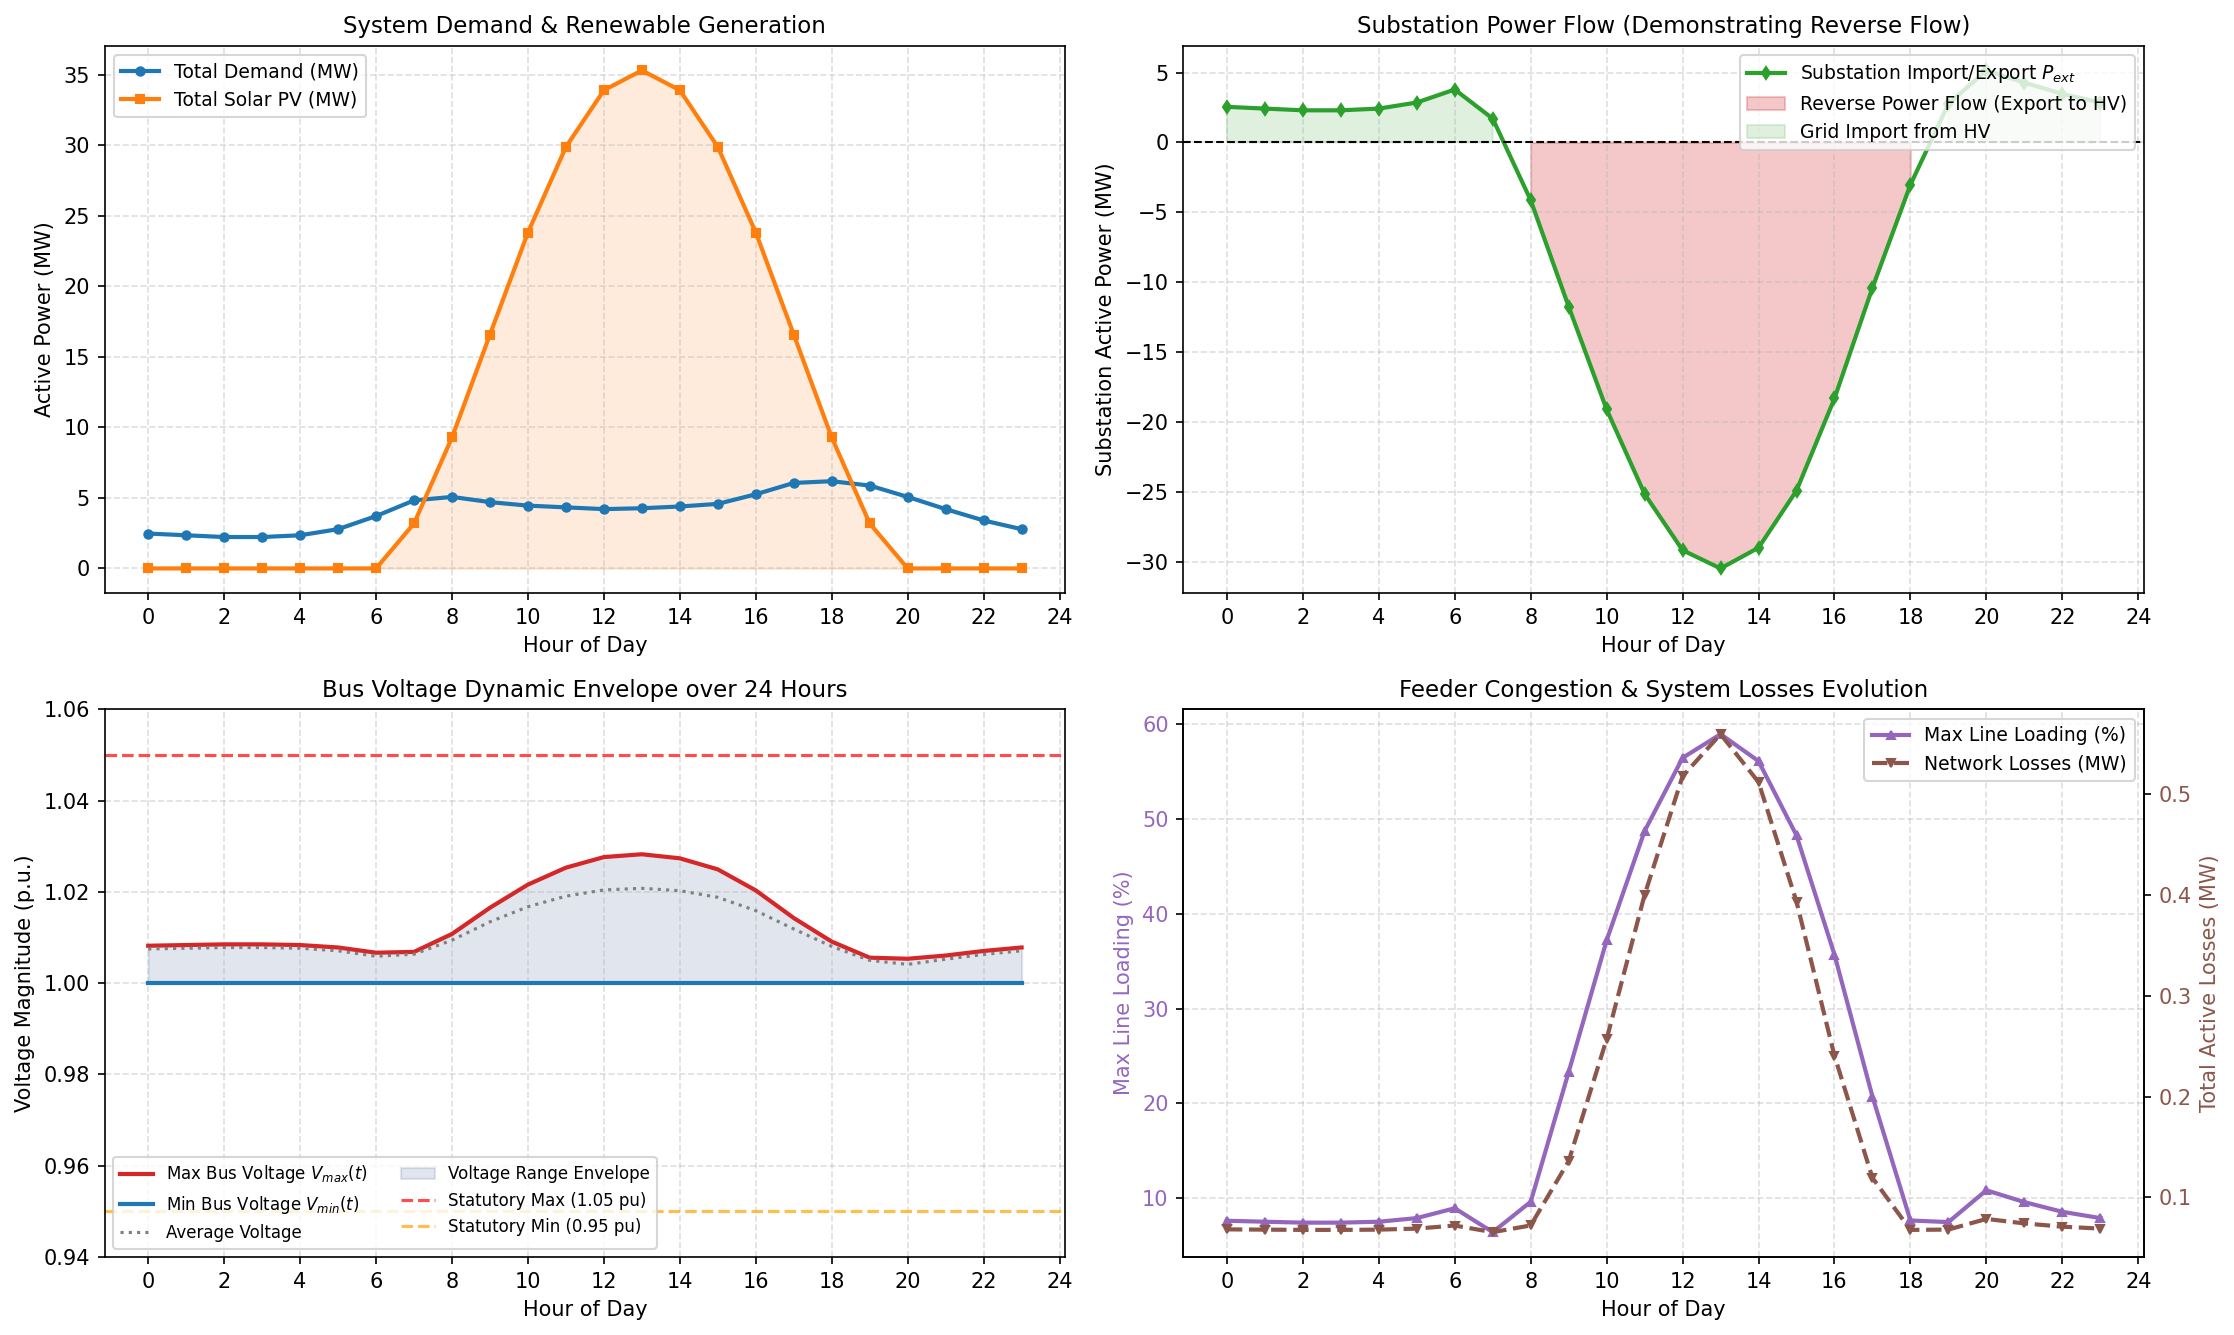

In [9]:
fig_ts = plot_timeseries_dashboard(ts_results)
plt.show()

---
## 7. Engineering Insights & Discussion

1. **Impact of Meshed vs. Radial Operation**:
   - In radial networks, line tripping isolates downstream feeders. By operating in closed-loop / meshed configuration, continuity of supply is preserved, but parallel corridors absorb the redirected power flow.
   - For example, tripping Line 161 caused the loading on parallel corridor Line 189 to increase by nearly $20\%$.

2. **Reverse Power Flow & Substation Transformer Sizing**:
   - During peak solar hours (11:00 - 15:00), the network transitions from a net consumer ($+3.5$ MW import) to a massive net exporter (up to $-30.5$ MW export back to the 110 kV transmission grid).
   - Distribution system operators (DSOs) must verify that substation transformers and reverse-power protection relays can accommodate reverse power flows without tripping.

3. **Voltage Regulation & Hosting Capacity**:
   - Distributed active power injections raise local voltage according to the approximate relation:
     $$\Delta V \approx \frac{R P + X Q}{V_n}$$
   - Because medium voltage lines possess non-negligible resistance ($R/X$ ratio is higher than in transmission), active power $P$ strongly couples to voltage magnitude $V$. Voltage control measures (e.g. inverter $Q(V)$ or $P(V)$ control, on-load tap changers) become essential to maintain voltage within the $[0.95, 1.05]$ p.u. band as renewable penetration expands.